In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import golden
from collections import defaultdict
import os
import numpy as np 

# Keep your existing constants
ONE_COL_WIDTH_INCH = 2.75
TWO_COL_WIDTH_INCH = 5.5
ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = ONE_COL_WIDTH_INCH / golden
TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH / golden

plt.style.use("lamalab.mplstyle")


Bad key font.dir in file lamalab.mplstyle, line 56 ('font.dir: /home/so87pot/n0w0f/attention_analysis/fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


Plots saved as fig2/gcmg_ngram_comparison_plot.png and fig2/gcmg_ngram_comparison_plot.pdf


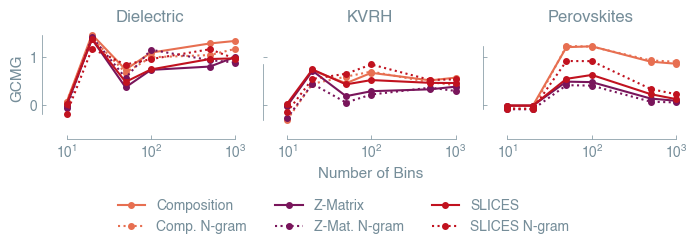

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.integrate import trapz # No longer needed for GCMG
import json
from scipy.constants import golden
import os # Added for robust path handling

# Ensure the custom style file is in the same directory or accessible via matplotlib's style path
# If 'lamalab.mplstyle' is not found, matplotlib will use a default style.
try:
    plt.style.use("lamalab.mplstyle")
except OSError:
    print("Warning: 'lamalab.mplstyle' not found. Using default matplotlib style.")


# Constants
ONE_COL_WIDTH_INCH = 3.25
TWO_COL_WIDTH_INCH = 7.2
ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = ONE_COL_WIDTH_INCH / golden
TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH / golden

GROUP_STYLES = {
    'compositional': {
        'color': '#e76f51',
        'members': {
            'composition': {'label': 'Composition', 'style': '-'},
            'composition_ngram': {'label': 'Comp. N-gram', 'style': ':'},
            # 'atom_sequences_plusplus': {'label': 'Atom Seq.++', 'style': '-.'}
        }
    },
    'geometric': {
        'color': '#79155B',
        'members': {
            # 'crystal_text_llm': {'label': 'Crystal-text-LLM', 'style': '-'},
            # 'crystal_text_llm_ngram': {'label': 'Crystal N-gram', 'style': '--'},
            # 'cif_p1': {'label': 'CIF P$_1$', 'style': '-.'},
            # 'cif_p1_ngram': {'label': 'CIF P$_1$ N-gram', 'style': ':'},
            'zmatrix': {'label': 'Z-Matrix', 'style': '-'},
            'zmatrix_ngram': {'label': 'Z-Mat. N-gram', 'style': ':'}
        }
    },
    'local': {
        'color': '#c1121f',
        'members': {
            'slices': {'label': 'SLICES', 'style': '-'},
            'slices_ngram': {'label': 'SLICES N-gram', 'style': ':'},
            # 'local_env': {'label': 'Local Env.', 'style': '-.'},
            # 'local_env_ngram': {'label': 'Local Env. N-gram', 'style': ':'}
        }
    }
}

# Updated group styles with n-gram handling
GROUP_STYLES = {
    'compositional': {
        'color': '#e76f51',
        'members': {
            'composition': {'label': 'Composition', 'style': '-'},
            'composition_ngram': {'label': 'Comp. N-gram', 'style': ':'},
            # 'atom_sequences_plusplus': {'label': 'Atom Seq.++', 'style': '-.'}
        }
    },
    'geometric': {
        'color': '#79155B',
        'members': {
            # 'crystal_text_llm': {'label': 'Crystal-text-LLM', 'style': '-'},
            # 'crystal_text_llm_ngram': {'label': 'Crystal N-gram', 'style': '--'},
            # 'cif_p1': {'label': 'CIF P$_1$', 'style': '-.'},
            # 'cif_p1_ngram': {'label': 'CIF P$_1$ N-gram', 'style': ':'},
            'zmatrix': {'label': 'Z-Matrix', 'style': '-'},
            'zmatrix_ngram': {'label': 'Z-Mat. N-gram', 'style': ':'}
        }
    },
    'local': {
        'color': '#c1121f',
        'members': {
            'slices': {'label': 'SLICES', 'style': '-'},
            'slices_ngram': {'label': 'SLICES N-gram', 'style': ':'},
            # 'local_env': {'label': 'Local Env.', 'style': '-.'},
            # 'local_env_ngram': {'label': 'Local Env. N-gram', 'style': ':'}
        }
    }
}

def range_frame(ax, x, y, pad=0.25):
    """Adjust plot ranges and frame with padding"""
    if not y: # Handle cases where y might be empty
        y_min, y_max = 0, 1 # Default range if no y data
    else:
        y_min, y_max = np.min(y), np.max(y)
    
    if not x: # Handle cases where x might be empty
        x_min, x_max = 0, 1 # Default range if no x data
    else:
        x_min, x_max = np.min(x), np.max(x)

    if y_min == y_max: # Avoid division by zero if all y values are the same
        y_min -= 0.1 * abs(y_min) if y_min != 0 else 0.1
        y_max += 0.1 * abs(y_max) if y_max != 0 else 0.1
        if y_min == y_max: # Still same (e.g. all zeros)
            y_min -= 0.5
            y_max += 0.5

    if x_min == x_max: # Avoid issues if all x values are the same for log scale
         x_min = x_min * 0.9 if x_min > 0 else -0.1
         x_max = x_max * 1.1 if x_max > 0 else 0.1
         if x_min == 0 and x_max == 0: x_max = 1.0 # Special case for all zero x for log

    # Set y-axis limits with padding
    ax.set_ylim(y_min - pad * (y_max - y_min),
                y_max + pad * (y_max - y_min))

    # Set x-axis limits with padding (considering log scale)
    if ax.get_xscale() == 'log':
        if x_min <= 0 : # log scale cannot handle non-positive values well for limits
             effective_x_min = np.min([val for val in x if val > 0]) if any(val > 0 for val in x) else 0.1
        else:
            effective_x_min = x_min
        ax.set_xlim(effective_x_min * (1 - pad),
                    x_max * (1 + pad))
    else:
        ax.set_xlim(x_min - pad * (x_max - x_min),
                    x_max + pad * (x_max - x_min))

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Position left and bottom spines
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))

    # Set spine bounds
    # Ensure bounds are within the actual data range if padding made them too wide for spines
    spine_y_min, spine_y_max = (np.min(y), np.max(y)) if y else (0,1)
    spine_x_min, spine_x_max = (np.min(x), np.max(x)) if x else (0,1)
    if spine_y_min == spine_y_max: spine_y_min, spine_y_max = spine_y_min -0.5, spine_y_max+0.5
    if spine_x_min == spine_x_max: spine_x_min, spine_x_max = spine_x_min*0.9 if spine_x_min > 0 else -0.1, spine_x_max*1.1 if spine_x_max > 0 else 0.1


    ax.spines['left'].set_bounds(spine_y_min, spine_y_max)
    ax.spines['bottom'].set_bounds(spine_x_min, spine_x_max)


def compute_gcmg(alpha_loss_data_dict):
    """
    Compute Geometry-Composition Modeling Gap (GCMG).
    GCMG = [ (loss@0 - loss@0.5) +  (loss@0.2 -loss@0.5) + (loss@0.4 -loss@0.5) ] -
           [ (loss@1 - loss@0.5) +  (loss@0.8 -loss@0.5) + (loss@0.6 -loss@0.5) ]

    Args:
        alpha_loss_data_dict (dict): A dictionary where keys are alpha strings (e.g., "0", "0.2")
                                     and values are dictionaries containing "eval_loss".
                                     Example: {"0": {"eval_loss": 0.1}, "0.2": {"eval_loss": 0.08}, ...}
    Returns:
        float or None: The computed GCMG value, or None if required data is missing.
    """
    required_alphas = ["0", "0.2", "0.4", "0.5", "0.6", "0.8", "1"]
    losses_at_alpha = {}

    for req_alpha in required_alphas:
        if req_alpha in alpha_loss_data_dict and "eval_loss" in alpha_loss_data_dict[req_alpha]:
            losses_at_alpha[req_alpha] = alpha_loss_data_dict[req_alpha]["eval_loss"]
        else:
            # print(f"Warning: Eval_loss for alpha '{req_alpha}' not found in provided data. Cannot compute GCMG for this entry.")
            return None

    l0, l02, l04, l05, l06, l08, l1 = (
        losses_at_alpha["0"], losses_at_alpha["0.2"], losses_at_alpha["0.4"],
        losses_at_alpha["0.5"], losses_at_alpha["0.6"], losses_at_alpha["0.8"],
        losses_at_alpha["1"]
    )

    geometry_contribution = (l0 - l05) + (l02 - l05) + (l04 - l05)
    composition_contribution = (l1 - l05) + (l08 - l05) + (l06 - l05)

    gcmg = geometry_contribution - composition_contribution
    return gcmg

def create_gcmg_plot(data_path):
    """Create the GCMG plot with grouped representations"""
    # Load data
    try:
        with open(data_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: Data file '{data_path}' not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from '{data_path}'.")
        return


    # Extract metadata
    bins = data.get('metadata', {}).get('bins', [])
    properties = data.get('metadata', {}).get('properties', [])
    # alphas_metadata = data.get('metadata', {}).get('alphas', []) # Not directly used by compute_gcmg but good to know it exists

    if not bins or not properties:
        print("Error: 'bins' or 'properties' missing from metadata in the JSON file.")
        return
        
    property_titles = ['Dielectric', 'KVRH', 'Perovskites'] # Assuming these match order and names in properties
    if len(properties) != len(property_titles):
        print(f"Warning: Mismatch between number of properties in JSON ({len(properties)}) and predefined titles ({len(property_titles)}). Using JSON properties.")
        property_titles = [p.replace("_", " ").title() for p in properties]


    # Compute GCMG values
    gcmg_values = {prop: {} for prop in properties}
    for bin_num_int in bins:
        bin_num_str = str(bin_num_int) # JSON keys for bins are strings
        bin_data = data.get('data', {}).get(bin_num_str, {})
        if not bin_data:
            # print(f"Warning: No data found for bin '{bin_num_str}'.")
            continue

        for group_name, group_style in GROUP_STYLES.items():
            for rep_name in group_style['members'].keys():
                if rep_name in bin_data:
                    for prop_idx, prop_name in enumerate(properties):
                        if prop_name in bin_data[rep_name]:
                            # The alpha_loss_data_dict is bin_data[rep_name][prop_name]
                            gcmg_val = compute_gcmg(bin_data[rep_name][prop_name])
                            if gcmg_val is not None:
                                if rep_name not in gcmg_values[prop_name]:
                                    gcmg_values[prop_name][rep_name] = []
                                # Ensure we append in the order of bins
                                # This assumes the outer loop iterates bins in the desired order
                                gcmg_values[prop_name][rep_name].append(gcmg_val)
                        # else:
                            # print(f"Property {prop_name} not in {rep_name} for bin {bin_num_str}")
                # else:
                    # print(f"Representation {rep_name} not in bin {bin_num_str}")


    # Create plots
    fig, axs = plt.subplots(1, len(properties), figsize=(TWO_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH), sharey=True)
    if len(properties) == 1: # If only one property, axs is not a list
        axs = [axs]

    for idx, (prop_name, title) in enumerate(zip(properties, property_titles)):
        ax = axs[idx]
        all_y_values_for_prop = []
        plotted_something = False

        # Plot each group
        for group_name, group_style in GROUP_STYLES.items():
            for rep_name, rep_style in group_style['members'].items():
                if prop_name in gcmg_values and rep_name in gcmg_values[prop_name]:
                    y_values = gcmg_values[prop_name][rep_name]
                    # Ensure y_values has the same length as bins if some GCMG were None
                    # This part is tricky if compute_gcmg returns None for some bins.
                    # The current logic appends GCMG values sequentially. If a bin is skipped
                    # for a representation, its y_values list will be shorter than 'bins'.
                    # For simplicity, we assume compute_gcmg either succeeds for all bins for a rep/prop
                    # or we plot what we have. A more robust solution might involve NaN padding.
                    
                    # We need to ensure x-values (bins) align with y_values.
                    # The current gcmg_values structure stores lists of y_values per rep/prop.
                    # These lists are built by iterating through 'bins' from metadata.
                    # So, the length of y_values should correspond to the number of bins for which
                    # GCMG was successfully computed. If it's less than len(bins), some were skipped.
                    # For now, we plot against the full 'bins' list, assuming that if a value is missing,
                    # it means it wasn't computed for that bin. This could lead to misaligned plots
                    # if compute_gcmg fails sporadically.
                    # A safer way: store (bin, gcmg_value) pairs, then extract x and y.
                    # However, given the current data processing loop, y_values should align with bins.
                    
                    if y_values and len(y_values) == len(bins): # Only plot if we have a GCMG for every bin
                        all_y_values_for_prop.extend(y_values)
                        ax.plot(bins, y_values,
                                marker='o',
                                markersize=4,
                                linestyle=rep_style['style'],
                                color=group_style['color'],
                                label=rep_style['label'],
                                linewidth=1.5)
                        plotted_something = True
                    # elif y_values:
                        # print(f"Warning: For {prop_name}/{rep_name}, expected {len(bins)} GCMG values, got {len(y_values)}. Plotting might be misaligned or skipped.")

        if idx == 1:
            ax.set_xlabel('Number of Bins')
        if idx == 0:
            ax.set_ylabel('GCMG') # Updated Y-axis label
        ax.set_title(f'{title}')
        ax.set_xscale('log')

        if plotted_something and all_y_values_for_prop:
            range_frame(ax, bins, all_y_values_for_prop)
        elif not plotted_something:
            ax.text(0.5, 0.5, "No data to plot", ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
            range_frame(ax, bins if bins else [1,1000], [0,1]) # Default frame if no data

    # Handle legend: collect from the last populated axis
    handles, labels = [], []
    for ax_ in axs[::-1]: # Iterate from last to first axis
        h, l = ax_.get_legend_handles_labels()
        if h: # Found an axis with legend items
            handles, labels = h, l
            break
            
    if handles:
        fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.25)) # Adjusted bbox_to_anchor
    else:
        print("No legend items to display.")

    plt.tight_layout()#(rect=[0, 0, 1, 0.95]) # Adjust rect to make space for legend if it's below
    
    output_dir = "fig2"
    os.makedirs(output_dir, exist_ok=True)  # Create directory if it doesn't exist
    output_filename_base = os.path.join(output_dir, "gcmg_ngram_comparison_plot")
    plt.savefig(f'{output_filename_base}.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'{output_filename_base}.pdf', bbox_inches='tight')
    print(f"Plots saved as {output_filename_base}.png and {output_filename_base}.pdf")
    plt.show()


    # Make sure this path is correct and the JSON file exists.
data_path = "../RESULTS_140925/BINNING_consolidated_results.json"



create_gcmg_plot(data_path)

In [ ]:
# Updated group styles with n-gram handling
GROUP_STYLES = {
    'compositional': {
        'color': '#e76f51',
        'members': {
            'composition': {'label': 'Composition', 'style': '-'},
            'composition_ngram': {'label': 'Comp. N-gram', 'style': '--'},
            # 'atom_sequences_plusplus': {'label': 'Atom Seq.++', 'style': '-.'}
        }
    },
    'geometric': {
        'color': '#79155B',
        'members': {
            # 'crystal_text_llm': {'label': 'Crystal-text-LLM', 'style': '-'},
            # 'crystal_text_llm_ngram': {'label': 'Crystal N-gram', 'style': '--'},
            # 'cif_p1': {'label': 'CIF P$_1$', 'style': '-.'},
            # 'cif_p1_ngram': {'label': 'CIF P$_1$ N-gram', 'style': ':'},
            'zmatrix': {'label': 'Z-Matrix', 'style': '-.'},
            'zmatrix_ngram': {'label': 'Z-Mat. N-gram', 'style': ':'}
        }
    },
    'local': {
        'color': '#c1121f',
        'members': {
            'slices': {'label': 'SLICES', 'style': '-'},
            'slices_ngram': {'label': 'SLICES N-gram', 'style': '--'},
            # 'local_env': {'label': 'Local Env.', 'style': '-.'},
            # 'local_env_ngram': {'label': 'Local Env. N-gram', 'style': ':'}
        }
    }
}


Bad key font.dir in file lamalab.mplstyle, line 56 ('font.dir: /home/so87pot/n0w0f/attention_analysis/fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


[0.06324662640690804, 1.4705392122268677, 0.7412524148821831, 1.09384086728096, 1.2848353125154972, 1.337558712810278, 0.07776604662812758, 1.4027319824766065, 0.6768377957216116, 0.9975821167423108, 1.0437281882641498, 1.172932502832459, -0.0031704548746347427, 1.5303195994347334, 0.5312064997851849, 0.8731969306245446, 1.2355051767081022, 1.0858020577579737, -0.08876405458785247, 1.704581354187326, 0.6227580465930742, 1.4557145600208008, 1.3719374782159115, 1.3320916057212542]
--------------
[-0.016468447633087635, 0.7241465002298355, 0.4581395536661148, 0.6740716099739075, 0.5178950354456902, 0.5739687029272318, -0.30507321755955613, 0.4468995480314011, 0.5952641563380776, 0.7000588554712447, 0.47716913863429455, 0.42004248047617787, -0.010065828217193484, 0.7124306820333004, 0.4326425539329648, 0.568884240463376, 0.4358942424878478, 0.46262111607939005, -0.23958781967995196, 0.4720404104615561, 0.7036829262796701, 0.8873073812286921, 0.49139810691997104, 0.5127667677474947]
-------

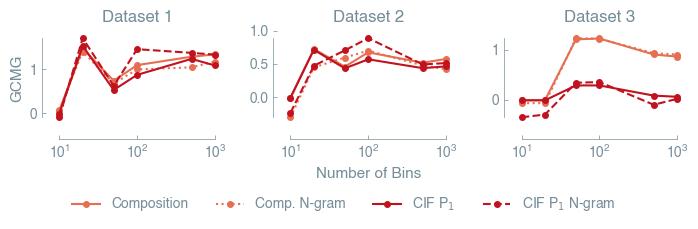

In [38]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.integrate import trapz # No longer needed for GCMG
import json
from scipy.constants import golden
import os # Added for robust path handling

# Ensure the custom style file is in the same directory or accessible via matplotlib's style path
# If 'lamalab.mplstyle' is not found, matplotlib will use a default style.
try:
    plt.style.use("lamalab.mplstyle")
except OSError:
    print("Warning: 'lamalab.mplstyle' not found. Using default matplotlib style.")


# Constants
ONE_COL_WIDTH_INCH = 3.25
TWO_COL_WIDTH_INCH = 7.2
ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = ONE_COL_WIDTH_INCH / golden
TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH / golden


# Updated group styles with n-gram handling
GROUP_STYLES = {
    'compositional': {
        'color': '#e76f51',
        'members': {
            'composition': {'label': 'Composition', 'style': '-'},
            'composition_ngram': {'label': 'Comp. N-gram', 'style': ':'},
            # 'atom_sequences_plusplus': {'label': 'Atom Seq.++', 'style': '-.'}
        }
    },
    'geometric': {
        'color': '#c1121f', #'#79155B',
        'members': {
            # 'crystal_text_llm': {'label': 'Crystal-text-LLM', 'style': '-'},
            # 'crystal_text_llm_ngram': {'label': 'Crystal N-gram', 'style': '--'},
            'cif_p1': {'label': 'CIF P$_1$', 'style': '-'},
            'cif_p1_ngram': {'label': 'CIF P$_1$ N-gram', 'style': '--'},
            # 'zmatrix': {'label': 'Z-Matrix', 'style': '-'},
            # 'zmatrix_ngram': {'label': 'Z-Mat. N-gram', 'style': ':'}
        }
    },
    'local': {
        'color': '#c1121f',
        'members': {
            # 'slices': {'label': 'SLICES', 'style': '-'},
            # 'slices_ngram': {'label': 'SLICES N-gram', 'style': ':'},
            # 'local_env': {'label': 'Local Env.', 'style': '-.'},
            # 'local_env_ngram': {'label': 'Local Env. N-gram', 'style': ':'}
        }
    }
}

map_properties_to_titles = {
    'dielectric': 'Dielectric',
    'kvrh': 'KVRH',
    'perovskites': 'Perovskites'
}
def range_frame(ax, x, y, pad=0.1):
    """
    Improved range_frame function that handles edge cases better
    """
    # Convert to numpy arrays for easier handling
    x = np.array(x)
    y = np.array(y)
    
    
    # Calculate ranges
    y_min, y_max = np.min(y), np.max(y)
    x_min, x_max = np.min(x), np.max(x)
    

    
    if x_min == x_max:
        if x_min > 0:  # For log scale
            x_min *= 0.5
            x_max *= 2.0
        else:
            x_min -= 1
            x_max += 1
    
    # Calculate padding
    y_range = y_max - y_min
    x_range = x_max - x_min
    
    # Set limits
    ax.set_ylim(y_min - pad * y_range, y_max + pad * y_range)
    
    # Handle x-axis limits for log scale
    if ax.get_xscale() == 'log':
        # Ensure positive values for log scale
        if x_min <= 0:
            x_min = min(x[x > 0]) if np.any(x > 0) else 0.1
        
        # Use multiplicative padding for log scale
        log_pad = 1 + pad
        ax.set_xlim(x_min / log_pad, x_max * log_pad)
    else:
        ax.set_xlim(x_min - pad * x_range, x_max + pad * x_range)
    
    # Set spine properties
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    
    # Set spine bounds to actual data range (not padded range)
    ax.spines["left"].set_bounds(np.min(y), np.max(y))
    ax.spines["bottom"].set_bounds(np.min(x), np.max(x))




def compute_gcmg(alpha_loss_data_dict):
    """
    Compute Geometry-Composition Modeling Gap (GCMG).
    GCMG = [ (loss@0 - loss@0.5) +  (loss@0.2 -loss@0.5) + (loss@0.4 -loss@0.5) ] -
           [ (loss@1 - loss@0.5) +  (loss@0.8 -loss@0.5) + (loss@0.6 -loss@0.5) ]

    Args:
        alpha_loss_data_dict (dict): A dictionary where keys are alpha strings (e.g., "0", "0.2")
                                     and values are dictionaries containing "eval_loss".
                                     Example: {"0": {"eval_loss": 0.1}, "0.2": {"eval_loss": 0.08}, ...}
    Returns:
        float or None: The computed GCMG value, or None if required data is missing.
    """
    required_alphas = ["0", "0.2", "0.4", "0.5", "0.6", "0.8", "1"]
    losses_at_alpha = {}

    for req_alpha in required_alphas:
        if req_alpha in alpha_loss_data_dict and "eval_loss" in alpha_loss_data_dict[req_alpha]:
            losses_at_alpha[req_alpha] = alpha_loss_data_dict[req_alpha]["eval_loss"]
        else:
            # print(f"Warning: Eval_loss for alpha '{req_alpha}' not found in provided data. Cannot compute GCMG for this entry.")
            return None

    l0, l02, l04, l05, l06, l08, l1 = (
        losses_at_alpha["0"], losses_at_alpha["0.2"], losses_at_alpha["0.4"],
        losses_at_alpha["0.5"], losses_at_alpha["0.6"], losses_at_alpha["0.8"],
        losses_at_alpha["1"]
    )

    geometry_contribution = (l0 - l05) + (l02 - l05) + (l04 - l05)
    composition_contribution = (l1 - l05) + (l08 - l05) + (l06 - l05)

    gcmg = geometry_contribution - composition_contribution
    return gcmg

def create_gcmg_plot(data_path):
    """Create the GCMG plot with grouped representations"""
    # Load data
    try:
        with open(data_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: Data file '{data_path}' not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from '{data_path}'.")
        return


    # Extract metadata
    bins = data.get('metadata', {}).get('bins', [])
    properties = data.get('metadata', {}).get('properties', [])
    # alphas_metadata = data.get('metadata', {}).get('alphas', []) # Not directly used by compute_gcmg but good to know it exists

    if not bins or not properties:
        print("Error: 'bins' or 'properties' missing from metadata in the JSON file.")
        return
        
    property_titles = ['Dataset 1', 'Dataset 2', 'Dataset 3'] # Assuming these match order and names in properties
    if len(properties) != len(property_titles):
        print(f"Warning: Mismatch between number of properties in JSON ({len(properties)}) and predefined titles ({len(property_titles)}). Using JSON properties.")
        property_titles = [p.replace("_", " ").title() for p in properties]


    # Compute GCMG values
    gcmg_values = {prop: {} for prop in properties}
    for bin_num_int in bins:
        bin_num_str = str(bin_num_int) # JSON keys for bins are strings
        bin_data = data.get('data', {}).get(bin_num_str, {})
        if not bin_data:
            # print(f"Warning: No data found for bin '{bin_num_str}'.")
            continue

        for group_name, group_style in GROUP_STYLES.items():
            for rep_name in group_style['members'].keys():
                if rep_name in bin_data:
                    for prop_idx, prop_name in enumerate(properties):
                        if prop_name in bin_data[rep_name]:
                            # The alpha_loss_data_dict is bin_data[rep_name][prop_name]
                            gcmg_val = compute_gcmg(bin_data[rep_name][prop_name])
                            if gcmg_val is not None:
                                if rep_name not in gcmg_values[prop_name]:
                                    gcmg_values[prop_name][rep_name] = []
                                # Ensure we append in the order of bins
                                # This assumes the outer loop iterates bins in the desired order
                                gcmg_values[prop_name][rep_name].append(gcmg_val)
                        # else:
                            # print(f"Property {prop_name} not in {rep_name} for bin {bin_num_str}")
                # else:
                    # print(f"Representation {rep_name} not in bin {bin_num_str}")


    # Create plots
    fig, axs = plt.subplots(1, len(properties), figsize=(TWO_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH), sharey=False)
    if len(properties) == 1: # If only one property, axs is not a list
        axs = [axs]

    for idx, (prop_name, title) in enumerate(zip(properties, property_titles)):
        ax = axs[idx]
        all_y_values_for_prop = []
        plotted_something = False

        # Plot each group
        for group_name, group_style in GROUP_STYLES.items():
            for rep_name, rep_style in group_style['members'].items():
                if prop_name in gcmg_values and rep_name in gcmg_values[prop_name]:
                    y_values = gcmg_values[prop_name][rep_name]
                    # Ensure y_values has the same length as bins if some GCMG were None
                    # This part is tricky if compute_gcmg returns None for some bins.
                    # The current logic appends GCMG values sequentially. If a bin is skipped
                    # for a representation, its y_values list will be shorter than 'bins'.
                    # For simplicity, we assume compute_gcmg either succeeds for all bins for a rep/prop
                    # or we plot what we have. A more robust solution might involve NaN padding.
                    
                    # We need to ensure x-values (bins) align with y_values.
                    # The current gcmg_values structure stores lists of y_values per rep/prop.
                    # These lists are built by iterating through 'bins' from metadata.
                    # So, the length of y_values should correspond to the number of bins for which
                    # GCMG was successfully computed. If it's less than len(bins), some were skipped.
                    # For now, we plot against the full 'bins' list, assuming that if a value is missing,
                    # it means it wasn't computed for that bin. This could lead to misaligned plots
                    # if compute_gcmg fails sporadically.
                    # A safer way: store (bin, gcmg_value) pairs, then extract x and y.
                    # However, given the current data processing loop, y_values should align with bins.
                    
                    if y_values and len(y_values) == len(bins): # Only plot if we have a GCMG for every bin
                        all_y_values_for_prop.extend(y_values)
                        ax.plot(bins, y_values,
                                marker='o',
                                markersize=4,
                                linestyle=rep_style['style'],
                                color=group_style['color'],
                                label=rep_style['label'],
                                linewidth=1.5)
                        plotted_something = True
                    # elif y_values:
                        # print(f"Warning: For {prop_name}/{rep_name}, expected {len(bins)} GCMG values, got {len(y_values)}. Plotting might be misaligned or skipped.")

        if idx == 1:
            ax.set_xlabel('Number of Bins')
        if idx == 0:
            ax.set_ylabel('GCMG') # Updated Y-axis label
        ax.set_title(f'{title}')
        ax.set_xscale('log')

        if plotted_something and all_y_values_for_prop:
            print(all_y_values_for_prop)
            print("--------------")
            range_frame(ax, bins, all_y_values_for_prop)
        elif not plotted_something:
            ax.text(0.5, 0.5, "No data to plot", ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
            range_frame(ax, bins if bins else [1,1000], [0,1]) # Default frame if no data

    # Handle legend: collect from the last populated axis
    handles, labels = [], []
    for ax_ in axs[::-1]: # Iterate from last to first axis
        h, l = ax_.get_legend_handles_labels()
        if h: # Found an axis with legend items
            handles, labels = h, l
            break
            
    if handles:
        fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.15)) # Adjusted bbox_to_anchor
    else:
        print("No legend items to display.")

    plt.tight_layout()#(rect=[0, 0, 1, 0.95]) # Adjust rect to make space for legend if it's below
    
    output_dir = "fig2"
    os.makedirs(output_dir, exist_ok=True)  # Create directory if it doesn't exist
    output_filename_base = os.path.join(output_dir, "gcmg_ngram_comparison_plot_cif_comp_rep_withoutshared")
    plt.savefig(f'{output_filename_base}.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'{output_filename_base}.pdf', bbox_inches='tight')
    print(f"Plots saved as {output_filename_base}.png and {output_filename_base}.pdf")
    plt.show()


    # Make sure this path is correct and the JSON file exists.
data_path = "../RESULTS_140925/BINNING_consolidated_results.json"



create_gcmg_plot(data_path)


Bad key font.dir in file lamalab.mplstyle, line 56 ('font.dir: /home/so87pot/n0w0f/attention_analysis/fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


Plots saved as fig2/gcmg_ngram_comparison_plot_cllm_rep.png and fig2/gcmg_ngram_comparison_plot_cllm_rep.pdf


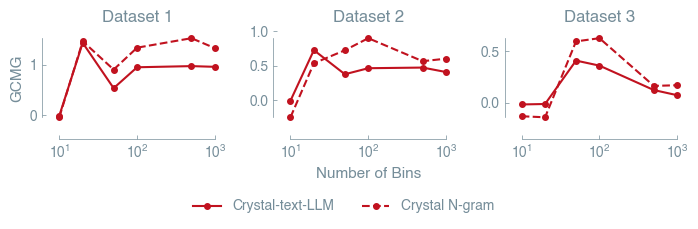

In [24]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.integrate import trapz # No longer needed for GCMG
import json
from scipy.constants import golden
import os # Added for robust path handling

# Ensure the custom style file is in the same directory or accessible via matplotlib's style path
# If 'lamalab.mplstyle' is not found, matplotlib will use a default style.
try:
    plt.style.use("lamalab.mplstyle")
except OSError:
    print("Warning: 'lamalab.mplstyle' not found. Using default matplotlib style.")


# Constants
ONE_COL_WIDTH_INCH = 3.25
TWO_COL_WIDTH_INCH = 7.2
ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = ONE_COL_WIDTH_INCH / golden
TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH / golden


# Updated group styles with n-gram handling
GROUP_STYLES = {
    'compositional': {
        'color': '#e76f51',
        'members': {
            # 'composition': {'label': 'Composition', 'style': '-'},
            # 'composition_ngram': {'label': 'Comp. N-gram', 'style': ':'},
            # 'atom_sequences_plusplus': {'label': 'Atom Seq.++', 'style': '-.'}
        }
    },
    'geometric': {
        'color': '#c1121f', #'#79155B',
        'members': {
            'crystal_text_llm': {'label': 'Crystal-text-LLM', 'style': '-'},
            'crystal_text_llm_ngram': {'label': 'Crystal N-gram', 'style': '--'},
            # 'cif_p1': {'label': 'CIF P$_1$', 'style': '-'},
            # 'cif_p1_ngram': {'label': 'CIF P$_1$ N-gram', 'style': '--'},
            # 'zmatrix': {'label': 'Z-Matrix', 'style': '-'},
            # 'zmatrix_ngram': {'label': 'Z-Mat. N-gram', 'style': ':'}
        }
    },
    'local': {
        'color': '#c1121f',
        'members': {
            # 'slices': {'label': 'SLICES', 'style': '-'},
            # 'slices_ngram': {'label': 'SLICES N-gram', 'style': ':'},
            # 'local_env': {'label': 'Local Env.', 'style': '-.'},
            # 'local_env_ngram': {'label': 'Local Env. N-gram', 'style': ':'}
        }
    }
}

map_properties_to_titles = {
    'dielectric': 'Dielectric',
    'kvrh': 'KVRH',
    'perovskites': 'Perovskites'
}
def range_frame(ax, x, y, pad=0.1):
    """
    Improved range_frame function that handles edge cases better
    """
    # Convert to numpy arrays for easier handling
    x = np.array(x)
    y = np.array(y)
    
    # Remove None values and ensure we have valid data
    valid_x_mask = ~np.isnan(x.astype(float)) if x.dtype != object else [val is not None for val in x]
    valid_y_mask = ~np.isnan(y.astype(float)) if y.dtype != object else [val is not None for val in y]
    
    if hasattr(x, 'dtype') and x.dtype == object:
        x_clean = np.array([val for val in x if val is not None])
    else:
        x_clean = x[valid_x_mask] if isinstance(valid_x_mask, np.ndarray) else x
        
    if hasattr(y, 'dtype') and y.dtype == object:
        y_clean = np.array([val for val in y if val is not None])
    else:
        y_clean = y[valid_y_mask] if isinstance(valid_y_mask, np.ndarray) else y
    
    # Handle empty data
    if len(x_clean) == 0:
        x_clean = np.array([1, 1000])  # Default for log scale
    if len(y_clean) == 0:
        y_clean = np.array([0, 1])
    
    # Calculate ranges
    y_min, y_max = np.min(y_clean), np.max(y_clean)
    x_min, x_max = np.min(x_clean), np.max(x_clean)
    
    # Handle case where all values are the same
    if y_min == y_max:
        y_range = max(abs(y_min) * 0.1, 0.1)
        y_min -= y_range
        y_max += y_range
    
    if x_min == x_max:
        if x_min > 0:  # For log scale
            x_min *= 0.5
            x_max *= 2.0
        else:
            x_min -= 1
            x_max += 1
    
    # Calculate padding
    y_range = y_max - y_min
    x_range = x_max - x_min
    
    # Set limits
    ax.set_ylim(y_min - pad * y_range, y_max + pad * y_range)
    
    # Handle x-axis limits for log scale
    if ax.get_xscale() == 'log':
        # Ensure positive values for log scale
        if x_min <= 0:
            x_min = min(x_clean[x_clean > 0]) if np.any(x_clean > 0) else 0.1
        
        # Use multiplicative padding for log scale
        log_pad = 1 + pad
        ax.set_xlim(x_min / log_pad, x_max * log_pad)
    else:
        ax.set_xlim(x_min - pad * x_range, x_max + pad * x_range)
    
    # Set spine properties
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    
    # Set spine bounds to actual data range (not padded range)
    ax.spines["left"].set_bounds(np.min(y_clean), np.max(y_clean))
    ax.spines["bottom"].set_bounds(np.min(x_clean), np.max(x_clean))




def compute_gcmg(alpha_loss_data_dict):
    """
    Compute Geometry-Composition Modeling Gap (GCMG).
    GCMG = [ (loss@0 - loss@0.5) +  (loss@0.2 -loss@0.5) + (loss@0.4 -loss@0.5) ] -
           [ (loss@1 - loss@0.5) +  (loss@0.8 -loss@0.5) + (loss@0.6 -loss@0.5) ]

    Args:
        alpha_loss_data_dict (dict): A dictionary where keys are alpha strings (e.g., "0", "0.2")
                                     and values are dictionaries containing "eval_loss".
                                     Example: {"0": {"eval_loss": 0.1}, "0.2": {"eval_loss": 0.08}, ...}
    Returns:
        float or None: The computed GCMG value, or None if required data is missing.
    """
    required_alphas = ["0", "0.2", "0.4", "0.5", "0.6", "0.8", "1"]
    losses_at_alpha = {}

    for req_alpha in required_alphas:
        if req_alpha in alpha_loss_data_dict and "eval_loss" in alpha_loss_data_dict[req_alpha]:
            losses_at_alpha[req_alpha] = alpha_loss_data_dict[req_alpha]["eval_loss"]
        else:
            # print(f"Warning: Eval_loss for alpha '{req_alpha}' not found in provided data. Cannot compute GCMG for this entry.")
            return None

    l0, l02, l04, l05, l06, l08, l1 = (
        losses_at_alpha["0"], losses_at_alpha["0.2"], losses_at_alpha["0.4"],
        losses_at_alpha["0.5"], losses_at_alpha["0.6"], losses_at_alpha["0.8"],
        losses_at_alpha["1"]
    )

    geometry_contribution = (l0 - l05) + (l02 - l05) + (l04 - l05)
    composition_contribution = (l1 - l05) + (l08 - l05) + (l06 - l05)

    gcmg = geometry_contribution - composition_contribution
    return gcmg

def create_gcmg_plot(data_path):
    """Create the GCMG plot with grouped representations"""
    # Load data
    try:
        with open(data_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: Data file '{data_path}' not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from '{data_path}'.")
        return


    # Extract metadata
    bins = data.get('metadata', {}).get('bins', [])
    properties = data.get('metadata', {}).get('properties', [])
    # alphas_metadata = data.get('metadata', {}).get('alphas', []) # Not directly used by compute_gcmg but good to know it exists

    if not bins or not properties:
        print("Error: 'bins' or 'properties' missing from metadata in the JSON file.")
        return
        
    property_titles = ['Dataset 1', 'Dataset 2', 'Dataset 3'] # Assuming these match order and names in properties
    if len(properties) != len(property_titles):
        print(f"Warning: Mismatch between number of properties in JSON ({len(properties)}) and predefined titles ({len(property_titles)}). Using JSON properties.")
        property_titles = [p.replace("_", " ").title() for p in properties]


    # Compute GCMG values
    gcmg_values = {prop: {} for prop in properties}
    for bin_num_int in bins:
        bin_num_str = str(bin_num_int) # JSON keys for bins are strings
        bin_data = data.get('data', {}).get(bin_num_str, {})
        if not bin_data:
            # print(f"Warning: No data found for bin '{bin_num_str}'.")
            continue

        for group_name, group_style in GROUP_STYLES.items():
            for rep_name in group_style['members'].keys():
                if rep_name in bin_data:
                    for prop_idx, prop_name in enumerate(properties):
                        if prop_name in bin_data[rep_name]:
                            # The alpha_loss_data_dict is bin_data[rep_name][prop_name]
                            gcmg_val = compute_gcmg(bin_data[rep_name][prop_name])
                            if gcmg_val is not None:
                                if rep_name not in gcmg_values[prop_name]:
                                    gcmg_values[prop_name][rep_name] = []
                                # Ensure we append in the order of bins
                                # This assumes the outer loop iterates bins in the desired order
                                gcmg_values[prop_name][rep_name].append(gcmg_val)
                        # else:
                            # print(f"Property {prop_name} not in {rep_name} for bin {bin_num_str}")
                # else:
                    # print(f"Representation {rep_name} not in bin {bin_num_str}")


    # Create plots
    fig, axs = plt.subplots(1, len(properties), figsize=(TWO_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH), sharey=False)
    if len(properties) == 1: # If only one property, axs is not a list
        axs = [axs]

    for idx, (prop_name, title) in enumerate(zip(properties, property_titles)):
        ax = axs[idx]
        all_y_values_for_prop = []
        plotted_something = False

        # Plot each group
        for group_name, group_style in GROUP_STYLES.items():
            for rep_name, rep_style in group_style['members'].items():
                if prop_name in gcmg_values and rep_name in gcmg_values[prop_name]:
                    y_values = gcmg_values[prop_name][rep_name]
                    # Ensure y_values has the same length as bins if some GCMG were None
                    # This part is tricky if compute_gcmg returns None for some bins.
                    # The current logic appends GCMG values sequentially. If a bin is skipped
                    # for a representation, its y_values list will be shorter than 'bins'.
                    # For simplicity, we assume compute_gcmg either succeeds for all bins for a rep/prop
                    # or we plot what we have. A more robust solution might involve NaN padding.
                    
                    # We need to ensure x-values (bins) align with y_values.
                    # The current gcmg_values structure stores lists of y_values per rep/prop.
                    # These lists are built by iterating through 'bins' from metadata.
                    # So, the length of y_values should correspond to the number of bins for which
                    # GCMG was successfully computed. If it's less than len(bins), some were skipped.
                    # For now, we plot against the full 'bins' list, assuming that if a value is missing,
                    # it means it wasn't computed for that bin. This could lead to misaligned plots
                    # if compute_gcmg fails sporadically.
                    # A safer way: store (bin, gcmg_value) pairs, then extract x and y.
                    # However, given the current data processing loop, y_values should align with bins.
                    
                    if y_values and len(y_values) == len(bins): # Only plot if we have a GCMG for every bin
                        all_y_values_for_prop.extend(y_values)
                        ax.plot(bins, y_values,
                                marker='o',
                                markersize=4,
                                linestyle=rep_style['style'],
                                color=group_style['color'],
                                label=rep_style['label'],
                                linewidth=1.5)
                        plotted_something = True
                    # elif y_values:
                        # print(f"Warning: For {prop_name}/{rep_name}, expected {len(bins)} GCMG values, got {len(y_values)}. Plotting might be misaligned or skipped.")

        if idx == 1:
            ax.set_xlabel('Number of Bins')
        if idx == 0:
            ax.set_ylabel('GCMG') # Updated Y-axis label
        ax.set_title(f'{title}')
        ax.set_xscale('log')

        if plotted_something and all_y_values_for_prop:
            range_frame(ax, bins, all_y_values_for_prop)
        elif not plotted_something:
            ax.text(0.5, 0.5, "No data to plot", ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
            range_frame(ax, bins if bins else [1,1000], [0,1]) # Default frame if no data

    # Handle legend: collect from the last populated axis
    handles, labels = [], []
    for ax_ in axs[::-1]: # Iterate from last to first axis
        h, l = ax_.get_legend_handles_labels()
        if h: # Found an axis with legend items
            handles, labels = h, l
            break
            
    if handles:
        fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.15)) # Adjusted bbox_to_anchor
    else:
        print("No legend items to display.")

    plt.tight_layout()#(rect=[0, 0, 1, 0.95]) # Adjust rect to make space for legend if it's below
    
    output_dir = "fig2"
    os.makedirs(output_dir, exist_ok=True)  # Create directory if it doesn't exist
    output_filename_base = os.path.join(output_dir, "gcmg_ngram_comparison_plot_cllm_rep")
    plt.savefig(f'{output_filename_base}.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'{output_filename_base}.pdf', bbox_inches='tight')
    print(f"Plots saved as {output_filename_base}.png and {output_filename_base}.pdf")
    plt.show()


    # Make sure this path is correct and the JSON file exists.
data_path = "../RESULTS_140925/BINNING_consolidated_results.json"



create_gcmg_plot(data_path)

In [ ]:
Dielectric  = 1
kvrh = 2
perovskites = 3


Bad key font.dir in file lamalab.mplstyle, line 56 ('font.dir: /home/so87pot/n0w0f/attention_analysis/fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


[0.06324662640690804, 1.4705392122268677, 0.7412524148821831, 1.09384086728096, 1.2848353125154972, 1.337558712810278, 0.07776604662812758, 1.4027319824766065, 0.6768377957216116, 0.9975821167423108, 1.0437281882641498, 1.172932502832459, -0.0031704548746347427, 1.5303195994347334, 0.5312064997851849, 0.8731969306245446, 1.2355051767081022, 1.0858020577579737, -0.08876405458785247, 1.704581354187326, 0.6227580465930742, 1.4557145600208008, 1.3719374782159115, 1.3320916057212542]
--------------
[-0.016468447633087635, 0.7241465002298355, 0.4581395536661148, 0.6740716099739075, 0.5178950354456902, 0.5739687029272318, -0.30507321755955613, 0.4468995480314011, 0.5952641563380776, 0.7000588554712447, 0.47716913863429455, 0.42004248047617787, -0.010065828217193484, 0.7124306820333004, 0.4326425539329648, 0.568884240463376, 0.4358942424878478, 0.46262111607939005, -0.23958781967995196, 0.4720404104615561, 0.7036829262796701, 0.8873073812286921, 0.49139810691997104, 0.5127667677474947]
-------

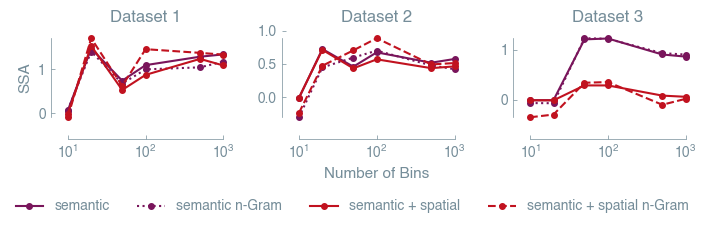

In [7]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.integrate import trapz # No longer needed for GCMG
import json
from scipy.constants import golden
import os # Added for robust path handling

# Ensure the custom style file is in the same directory or accessible via matplotlib's style path
# If 'lamalab.mplstyle' is not found, matplotlib will use a default style.
try:
    plt.style.use("lamalab.mplstyle")
except OSError:
    print("Warning: 'lamalab.mplstyle' not found. Using default matplotlib style.")


# Constants
ONE_COL_WIDTH_INCH = 3.25
TWO_COL_WIDTH_INCH = 7.2
ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = ONE_COL_WIDTH_INCH / golden
TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH / golden


# Updated group styles with n-gram handling
GROUP_STYLES = {
    'compositional': {
        'color': '#79155B',
        'members': {
            'composition': {'label': 'semantic', 'style': '-'},
            'composition_ngram': {'label': 'semantic n-Gram', 'style': ':'},
            # 'atom_sequences_plusplus': {'label': 'Atom Seq.++', 'style': '-.'}
        }
    },
    'geometric': {
        'color': '#c1121f', #'#79155B',
        'members': {
            # 'crystal_text_llm': {'label': 'Crystal-text-LLM', 'style': '-'},
            # 'crystal_text_llm_ngram': {'label': 'Crystal N-gram', 'style': '--'},
            'cif_p1': {'label': 'semantic + spatial', 'style': '-'},
            'cif_p1_ngram': {'label': 'semantic + spatial n-Gram', 'style': '--'},
            # 'zmatrix': {'label': 'Z-Matrix', 'style': '-'},
            # 'zmatrix_ngram': {'label': 'Z-Mat. N-gram', 'style': ':'}
        }
    },
    'local': {
        'color': '#c1121f',
        'members': {
            # 'slices': {'label': 'SLICES', 'style': '-'},
            # 'slices_ngram': {'label': 'SLICES N-gram', 'style': ':'},
            # 'local_env': {'label': 'Local Env.', 'style': '-.'},
            # 'local_env_ngram': {'label': 'Local Env. N-gram', 'style': ':'}
        }
    }
}

map_properties_to_titles = {
    'dielectric': 'Dielectric',
    'kvrh': 'KVRH',
    'perovskites': 'Perovskites'
}
def range_frame(ax, x, y, pad=0.1):
    """
    Improved range_frame function that handles edge cases better
    """
    # Convert to numpy arrays for easier handling
    x = np.array(x)
    y = np.array(y)
    
    
    # Calculate ranges
    y_min, y_max = np.min(y), np.max(y)
    x_min, x_max = np.min(x), np.max(x)
    

    
    if x_min == x_max:
        if x_min > 0:  # For log scale
            x_min *= 0.5
            x_max *= 2.0
        else:
            x_min -= 1
            x_max += 1
    
    # Calculate padding
    y_range = y_max - y_min
    x_range = x_max - x_min
    
    # Set limits
    ax.set_ylim(y_min - pad * y_range, y_max + pad * y_range)
    
    # Handle x-axis limits for log scale
    if ax.get_xscale() == 'log':
        # Ensure positive values for log scale
        if x_min <= 0:
            x_min = min(x[x > 0]) if np.any(x > 0) else 0.1
        
        # Use multiplicative padding for log scale
        log_pad = 1 + pad
        ax.set_xlim(x_min / log_pad, x_max * log_pad)
    else:
        ax.set_xlim(x_min - pad * x_range, x_max + pad * x_range)
    
    # Set spine properties
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    
    # Set spine bounds to actual data range (not padded range)
    ax.spines["left"].set_bounds(np.min(y), np.max(y))
    ax.spines["bottom"].set_bounds(np.min(x), np.max(x))




def compute_gcmg(alpha_loss_data_dict):
    """
    Compute Geometry-Composition Modeling Gap (GCMG).
    GCMG = [ (loss@0 - loss@0.5) +  (loss@0.2 -loss@0.5) + (loss@0.4 -loss@0.5) ] -
           [ (loss@1 - loss@0.5) +  (loss@0.8 -loss@0.5) + (loss@0.6 -loss@0.5) ]

    Args:
        alpha_loss_data_dict (dict): A dictionary where keys are alpha strings (e.g., "0", "0.2")
                                     and values are dictionaries containing "eval_loss".
                                     Example: {"0": {"eval_loss": 0.1}, "0.2": {"eval_loss": 0.08}, ...}
    Returns:
        float or None: The computed GCMG value, or None if required data is missing.
    """
    required_alphas = ["0", "0.2", "0.4", "0.5", "0.6", "0.8", "1"]
    losses_at_alpha = {}

    for req_alpha in required_alphas:
        if req_alpha in alpha_loss_data_dict and "eval_loss" in alpha_loss_data_dict[req_alpha]:
            losses_at_alpha[req_alpha] = alpha_loss_data_dict[req_alpha]["eval_loss"]
        else:
            # print(f"Warning: Eval_loss for alpha '{req_alpha}' not found in provided data. Cannot compute GCMG for this entry.")
            return None

    l0, l02, l04, l05, l06, l08, l1 = (
        losses_at_alpha["0"], losses_at_alpha["0.2"], losses_at_alpha["0.4"],
        losses_at_alpha["0.5"], losses_at_alpha["0.6"], losses_at_alpha["0.8"],
        losses_at_alpha["1"]
    )

    geometry_contribution = (l0 - l05) + (l02 - l05) + (l04 - l05)
    composition_contribution = (l1 - l05) + (l08 - l05) + (l06 - l05)

    gcmg = geometry_contribution - composition_contribution
    return gcmg

def create_gcmg_plot(data_path):
    """Create the GCMG plot with grouped representations"""
    # Load data
    try:
        with open(data_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: Data file '{data_path}' not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from '{data_path}'.")
        return


    # Extract metadata
    bins = data.get('metadata', {}).get('bins', [])
    properties = data.get('metadata', {}).get('properties', [])
    # alphas_metadata = data.get('metadata', {}).get('alphas', []) # Not directly used by compute_gcmg but good to know it exists

    if not bins or not properties:
        print("Error: 'bins' or 'properties' missing from metadata in the JSON file.")
        return
        
    property_titles = ['Dataset 1', 'Dataset 2', 'Dataset 3'] # Assuming these match order and names in properties
    if len(properties) != len(property_titles):
        print(f"Warning: Mismatch between number of properties in JSON ({len(properties)}) and predefined titles ({len(property_titles)}). Using JSON properties.")
        property_titles = [p.replace("_", " ").title() for p in properties]


    # Compute GCMG values
    gcmg_values = {prop: {} for prop in properties}
    for bin_num_int in bins:
        bin_num_str = str(bin_num_int) # JSON keys for bins are strings
        bin_data = data.get('data', {}).get(bin_num_str, {})
        if not bin_data:
            # print(f"Warning: No data found for bin '{bin_num_str}'.")
            continue

        for group_name, group_style in GROUP_STYLES.items():
            for rep_name in group_style['members'].keys():
                if rep_name in bin_data:
                    for prop_idx, prop_name in enumerate(properties):
                        if prop_name in bin_data[rep_name]:
                            # The alpha_loss_data_dict is bin_data[rep_name][prop_name]
                            gcmg_val = compute_gcmg(bin_data[rep_name][prop_name])
                            if gcmg_val is not None:
                                if rep_name not in gcmg_values[prop_name]:
                                    gcmg_values[prop_name][rep_name] = []
                                # Ensure we append in the order of bins
                                # This assumes the outer loop iterates bins in the desired order
                                gcmg_values[prop_name][rep_name].append(gcmg_val)
                        # else:
                            # print(f"Property {prop_name} not in {rep_name} for bin {bin_num_str}")
                # else:
                    # print(f"Representation {rep_name} not in bin {bin_num_str}")


    # Create plots
    fig, axs = plt.subplots(1, len(properties), figsize=(TWO_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH), sharey=False)
    if len(properties) == 1: # If only one property, axs is not a list
        axs = [axs]

    for idx, (prop_name, title) in enumerate(zip(properties, property_titles)):
        ax = axs[idx]
        all_y_values_for_prop = []
        plotted_something = False

        # Plot each group
        for group_name, group_style in GROUP_STYLES.items():
            for rep_name, rep_style in group_style['members'].items():
                if prop_name in gcmg_values and rep_name in gcmg_values[prop_name]:
                    y_values = gcmg_values[prop_name][rep_name]
                    # Ensure y_values has the same length as bins if some GCMG were None
                    # This part is tricky if compute_gcmg returns None for some bins.
                    # The current logic appends GCMG values sequentially. If a bin is skipped
                    # for a representation, its y_values list will be shorter than 'bins'.
                    # For simplicity, we assume compute_gcmg either succeeds for all bins for a rep/prop
                    # or we plot what we have. A more robust solution might involve NaN padding.
                    
                    # We need to ensure x-values (bins) align with y_values.
                    # The current gcmg_values structure stores lists of y_values per rep/prop.
                    # These lists are built by iterating through 'bins' from metadata.
                    # So, the length of y_values should correspond to the number of bins for which
                    # GCMG was successfully computed. If it's less than len(bins), some were skipped.
                    # For now, we plot against the full 'bins' list, assuming that if a value is missing,
                    # it means it wasn't computed for that bin. This could lead to misaligned plots
                    # if compute_gcmg fails sporadically.
                    # A safer way: store (bin, gcmg_value) pairs, then extract x and y.
                    # However, given the current data processing loop, y_values should align with bins.
                    
                    if y_values and len(y_values) == len(bins): # Only plot if we have a GCMG for every bin
                        all_y_values_for_prop.extend(y_values)
                        ax.plot(bins, y_values,
                                marker='o',
                                markersize=4,
                                linestyle=rep_style['style'],
                                color=group_style['color'],
                                label=rep_style['label'],
                                linewidth=1.5)
                        plotted_something = True
                    # elif y_values:
                        # print(f"Warning: For {prop_name}/{rep_name}, expected {len(bins)} GCMG values, got {len(y_values)}. Plotting might be misaligned or skipped.")

        if idx == 1:
            ax.set_xlabel('Number of Bins')
        if idx == 0:
            ax.set_ylabel('SSA') # Updated Y-axis label
        ax.set_title(f'{title}')
        ax.set_xscale('log')

        if plotted_something and all_y_values_for_prop:
            print(all_y_values_for_prop)
            print("--------------")
            range_frame(ax, bins, all_y_values_for_prop)
        elif not plotted_something:
            ax.text(0.5, 0.5, "No data to plot", ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
            range_frame(ax, bins if bins else [1,1000], [0,1]) # Default frame if no data

    # Handle legend: collect from the last populated axis
    handles, labels = [], []
    for ax_ in axs[::-1]: # Iterate from last to first axis
        h, l = ax_.get_legend_handles_labels()
        if h: # Found an axis with legend items
            handles, labels = h, l
            break
            
    if handles:
        fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.15)) # Adjusted bbox_to_anchor
    else:
        print("No legend items to display.")

    plt.tight_layout()#(rect=[0, 0, 1, 0.95]) # Adjust rect to make space for legend if it's below
    
    output_dir = "fig2"
    os.makedirs(output_dir, exist_ok=True)  # Create directory if it doesn't exist
    output_filename_base = os.path.join(output_dir, "ngram_comparison")
    plt.savefig(f'{output_filename_base}.png', bbox_inches='tight', dpi=300)
    plt.savefig(f'{output_filename_base}.pdf', bbox_inches='tight')
    print(f"Plots saved as {output_filename_base}.png and {output_filename_base}.pdf")
    plt.show()


    # Make sure this path is correct and the JSON file exists.
data_path = "../RESULTS_140925/BINNING_consolidated_results.json"



create_gcmg_plot(data_path)